<a href="https://colab.research.google.com/github/Yelmi95/IA_SIS420/blob/main/Lab04_multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 4 — Clasificación Multiclase Multimodal

**Nombre:** Alcibia Miranda Yulitza

Grupo:2

## Dataset Multimodal: Gestos de Mano (Hand Gestures)

URL: https://drive.google.com/drive/folders/1wuD5wpJbz3yYgZLJAz8WrMMGLrhbIebu?usp=sharing

---

### Descripción del Dataset

El dataset **Gestos de Mano** contiene imágenes en escala de grises de gestos realizados con la mano, con fondo negro uniforme y figura blanca centrada. Cada imagen se redimensiona a **20×20 píxeles** generando **400 features (n = 400)** por ejemplo.

**Número de features (n):** 400 (20×20 píxeles en escala de grises)  
**Número de ejemplos (m):** ~7,000 (~1,000 por clase)  
**Número de clases (K):** 7  

### Clases del Dataset

- `0` — fist → Puño cerrado  
- `1` — five → Mano abierta (cinco dedos)  
- `2` — okay → Signo OK  
- `3` — peace → Paz (dos dedos)  
- `4` — rad → Gesto rad  
- `5` — straight → Mano recta  
- `6` — thumbs → Pulgar arriba

### Estrategia del Modelo

Se aplica **Regresión Logística One-vs-All (OvR)**: para cada una de las **K = 7 clases** se entrena un clasificador binario independiente que aprende a distinguir esa clase del resto. La predicción final es la clase con mayor probabilidad:

$$\hat{y} = \arg\max_{k \in \{0,\ldots,K-1\}} \; h_\theta^{(k)}(x)$$

Esto equivale a entrenar **7 modelos de regresión logística**, uno por clase.

## 1. Importación de Librerías

Se importan las librerías necesarias para manipulación numérica, visualización, optimización y carga de imágenes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
from scipy import optimize
import cv2
import os
import glob
from matplotlib import pyplot
%matplotlib inline
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Montar Google Drive y Cargar el Dataset

Las imágenes están organizadas en subcarpetas por clase dentro de `data/train/`. Se usa `cv2` para leer cada imagen en escala de grises, se redimensiona a **20×20** y se aplana a un vector de **400 valores** normalizados entre 0 y 1.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado correctamente.')

Mounted at /content/drive
Drive montado correctamente.


In [ ]:
clases = ['fist', 'five', 'okay', 'peace', 'rad', 'straight', 'thumbs']
num_labels = len(clases)
input_layer_size = 20 * 20
ruta_base = '/content/drive/MyDrive/IA_sis420/LABORATORIOS/DATASET/data/'

def cargar_datos(carpeta):

    X_list = []
    y_list = []

    for etiqueta, clase in enumerate(clases):
        ruta = ruta_base + carpeta + '/' + clase + '/*.png'
        imagenes = glob.glob(ruta)

        for imagen_path in imagenes:
            imagen = cv2.imread(imagen_path, cv2.IMREAD_GRAYSCALE)
            imagen = cv2.resize(imagen, (20, 20))   # 20x20
            imagen = imagen.flatten() / 255.0        # normalizar a [0, 1]
            X_list.append(imagen)
            y_list.append(etiqueta)

    return np.array(X_list), np.array(y_list)

X_raw, y_raw = cargar_datos('train')

m_total = y_raw.size
print(f"Total imágenes cargadas: {X_raw.shape[0]}")
print(f"Features por imagen:     {X_raw.shape[1]}  (= 20x20)")
print(f"Clases encontradas:      {np.unique(y_raw)}  ({num_labels} clases)")

Total imágenes cargadas: 6999
Features por imagen:     400  (= 20x20)
Clases encontradas:      [0 1 2 3 4 5 6]  (7 clases)


## 3. División en Entrenamiento y Prueba

Se separa el dataset en **80% entrenamiento** y **20% prueba** usando `train_test_split` con `stratify=y_raw` para garantizar que cada clase esté representada proporcionalmente en ambos subconjuntos. El parámetro `random_state=42` asegura reproducibilidad.

In [ ]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

m = y.size

print(f"Entrenamiento: {X.shape[0]} imágenes  →  X shape: {X.shape}")
print(f"Prueba:        {X_test.shape[0]} imágenes  →  X_test shape: {X_test.shape}")

Entrenamiento: 5599 imágenes  →  X shape: (5599, 400)
Prueba:        1400 imágenes  →  X_test shape: (1400, 400)


## 4. Visualización del Dataset

Se muestran 100 imágenes aleatorias del conjunto de entrenamiento. La función `displayData` organiza las imágenes en una cuadrícula de √100 × √100 = 10×10 imágenes. Cada imagen se reconstruye como una matriz de 20×20 a partir de su vector de 400 features.

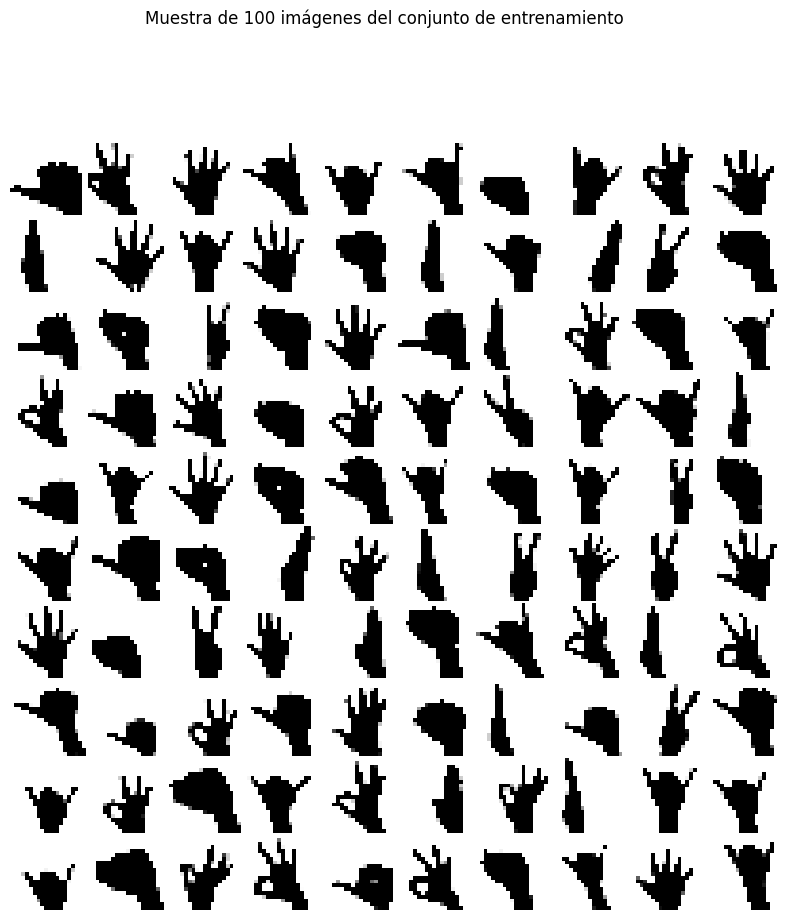

In [ ]:
def displayData(X, example_width=None, figsize=(10, 10)):

    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n // example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)
pyplot.suptitle('Muestra de 100 imágenes del conjunto de entrenamiento', y=1.01)
pyplot.show()

## 5. Implementación del Modelo: Regresión Logística One-vs-All

### 5.1 Fundamento Matemático

#### Función Sigmoide

La función sigmoide mapea cualquier valor real al rango (0, 1), permitiendo interpretar la salida como una probabilidad:

$$g(z) = \frac{1}{1 + e^{-z}}$$

#### Hipótesis

Para un clasificador binario de la clase $k$, la probabilidad de que el ejemplo $x$ pertenezca a la clase $k$ es:

$$h_\theta^{(k)}(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

#### Función de Costo Regularizada (L2)

$$J(\theta) = \frac{1}{m} \left[ -y^T \log(h) - (1-y)^T \log(1-h) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$



#### Gradiente Regularizado

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} X^T(h - y) \bigg|_{j=0}$$

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} X^T(h - y) + \frac{\lambda}{m}\theta_j \quad \text{para } j \geq 1$$

En forma vectorizada:

$$\nabla J(\theta) = \frac{1}{m} X^T(h - y) + \frac{\lambda}{m} \theta_{\text{reg}}$$

donde $\theta_{\text{reg}}$ es igual a $\theta$ pero con $\theta_0 = 0$.

In [ ]:
def sigmoid(z):

    return 1.0 / (1.0 + np.exp(-z))

In [ ]:
def lrCostFunction(theta, X, y, lambda_):

    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)


    h = sigmoid(X.dot(theta.T))


    temp = theta.copy()
    temp[0] = 0


    J = (1/m) * np.sum(-y.dot(np.log(h)) - (1-y).dot(np.log(1-h))) + \
        (lambda_/(2*m)) * np.sum(np.square(temp))


    grad = (1/m) * (h - y).dot(X) + (lambda_/m) * temp

    return J, grad

### 5.1.1 Verificación de lrCostFunction

Antes de entrenar con el dataset real, se verifica que la función de costo
esté correctamente implementada usando datos pequeños con valores conocidos.

In [ ]:
# Datos de prueba con valores conocidos
theta_t = np.array([-2, -1, 1, 2], dtype=float)
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)
y_t = np.array([1, 0, 1, 0, 1])
lambda_t = 3

J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo          : {:.6f}'.format(J))
print('Costo esperado : 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]')

Costo          : 2.534819
Costo esperado : 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


### 5.2 Entrenamiento: One-vs-All

Se entrenan **K = 7 clasificadores** binarios. Para cada clase $k$, las etiquetas se convierten en binario: $y_j = 1$ si el ejemplo $j$ pertenece a la clase $k$, y $y_j = 0$ en caso contrario.

Se usa `scipy.optimize.minimize` con el método **Gradiente Conjugado (CG)** para minimizar la función de costo, con `maxiter=50` iteraciones como en el notebook del profe.

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))

    # Agrega columna de unos (bias) a X → forma: (m, n+1)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50}

        # Etiquetas binarias: 1 si pertenece a clase c, 0 si no
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X, (y == c), lambda_),
            jac=True,
            method='CG',
            options=options
        )
        all_theta[c] = res.x
        print(f'  Clase {c} ({clases[c]:>10}): costo final = {res.fun:.4f}')

    return all_theta

lambda_ = 0.001
print('Entrenando clasificadores One-vs-All...')
all_theta = oneVsAll(X, y, num_labels, lambda_)
print(f'\nForma de all_theta: {all_theta.shape}')

Entrenando clasificadores One-vs-All...
  Clase 0 (      fist): costo final = 0.0235
  Clase 1 (      five): costo final = 0.0767
  Clase 2 (      okay): costo final = 0.0932
  Clase 3 (     peace): costo final = 0.0371
  Clase 4 (       rad): costo final = 0.0425
  Clase 5 (  straight): costo final = 0.0067
  Clase 6 (    thumbs): costo final = 0.0407

Forma de all_theta: (7, 401)


### 5.3 Predicción One-vs-All

Para predecir, se calcula la probabilidad de cada clase para cada ejemplo y se elige la clase con mayor probabilidad:

$$\hat{y}^{(i)} = \arg\max_{k} \; h_\theta^{(k)}(x^{(i)}) = \arg\max_{k} \; g\left( (\theta^{(k)})^T x^{(i)} \right)$$



In [ ]:
def predictOneVsAll(all_theta, X):

    m = X.shape[0]

    # Agrega columna de unos (bias) → forma: (m, n+1)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p

## 6. Evaluación del Modelo

In [ ]:
# Precisión en entrenamiento
pred_train = predictOneVsAll(all_theta, X)
acc_train = np.mean(pred_train == y) * 100

# Precisión en prueba
pred_test = predictOneVsAll(all_theta, X_test)
acc_test = np.mean(pred_test == y_test) * 100

print('=' * 40)
print(f'Precisión entrenamiento: {acc_train:.2f}%')
print(f'Precisión prueba:        {acc_test:.2f}%')
print('=' * 40)
print()
print('Una brecha grande entre entrenamiento y prueba')
print('indica sobreajuste (overfitting). Ajustar lambda_')
print('a un valor mayor puede ayudar a regularizar.')

Precisión entrenamiento: 97.27%
Precisión prueba:        95.50%

Una brecha grande entre entrenamiento y prueba
indica sobreajuste (overfitting). Ajustar lambda_
a un valor mayor puede ayudar a regularizar.


## 7. Visualización de Predicciones

Se muestra una muestra aleatoria de 100 imágenes con sus etiquetas reales y predichas.

Predicciones: ['thumbs', 'fist', 'rad', 'peace', 'straight', 'okay', 'five', 'rad', 'five', 'fist', 'fist', 'fist', 'okay', 'five', 'thumbs', 'thumbs', 'peace', 'okay', 'peace', 'thumbs', 'fist', 'straight', 'straight', 'thumbs', 'peace', 'okay', 'okay', 'thumbs', 'peace', 'straight', 'peace', 'straight', 'straight', 'five', 'fist', 'fist', 'five', 'thumbs', 'peace', 'peace', 'fist', 'straight', 'five', 'peace', 'five', 'five', 'fist', 'fist', 'peace', 'okay', 'straight', 'straight', 'peace', 'fist', 'thumbs', 'thumbs', 'straight', 'straight', 'fist', 'okay', 'fist', 'straight', 'five', 'okay', 'okay', 'peace', 'rad', 'straight', 'straight', 'five', 'fist', 'peace', 'thumbs', 'thumbs', 'straight', 'rad', 'straight', 'okay', 'fist', 'straight', 'thumbs', 'okay', 'five', 'five', 'peace', 'thumbs', 'rad', 'thumbs', 'straight', 'straight', 'rad', 'thumbs', 'peace', 'peace', 'five', 'fist', 'fist', 'peace', 'peace', 'rad']
Real:         ['thumbs', 'fist', 'rad', 'peace', 'straight', 'okay',

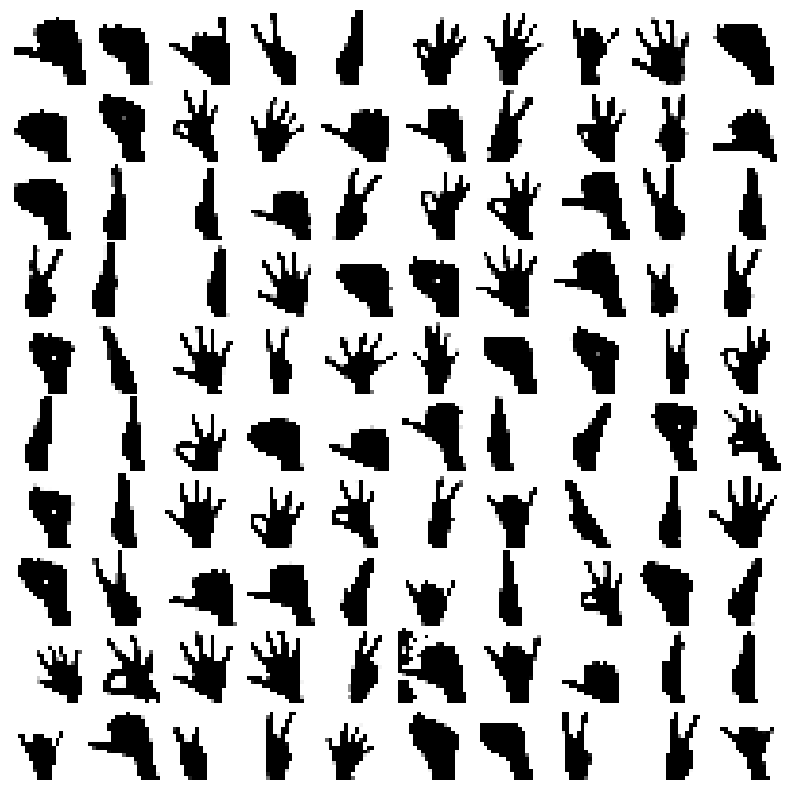

In [ ]:
rand_indices = np.random.choice(m, 100, replace=False)
X_muestra = X[rand_indices, :]
y_muestra = y[rand_indices]

pred_muestra = predictOneVsAll(all_theta, X_muestra)

displayData(X_muestra)

# Mostramos predicciones vs realidad
print('Predicciones:', [clases[i] for i in pred_muestra])
print('Real:        ', [clases[i] for i in y_muestra])
